# Notebook 03 — Model Training
## COM668 Final Year Project: AI-Based Intrusion Detection System
**Student:** Abdulbosit Abdurazzakov | **ID:** B00979380

---

### Purpose
This notebook trains both models on preprocessed CICIDS2017 data:
1. **Random Forest** — supervised binary classifier with 5-fold cross-validation
2. **Isolation Forest** — unsupervised anomaly detector trained on BENIGN traffic only

### Design Decisions
| Decision | Rationale |
|---|---|
| `class_weight='balanced'` in RF | Equivalent to RandomOverSampler (demonstrated in NB02); avoids ~1 GB memory cost of duplicating rows |
| float32 arrays | Halves memory footprint (4 bytes vs 8 bytes per value) — required for 1.67M × 78 dataset |
| CV on 300k sample | Full CV on 1.67M rows impractical; stratified sample gives reliable estimates |
| IF trained on BENIGN-only | Semi-supervised approach learns normal traffic boundary; detects novel attacks |
| IF contamination tuned empirically | True contamination rate unknown in deployment |


---
## 1. Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, warnings, time, gc

from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.model_selection import StratifiedKFold, cross_validate, StratifiedShuffleSplit
from sklearn.metrics import classification_report, f1_score

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

PROCESSED_DIR = '../data/processed'
MODELS_DIR    = '../models'
RESULTS_DIR   = '../results'
for d in [MODELS_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

print("Environment ready.")


Environment ready.


---
## 2. Load Preprocessing Artifacts

Artifacts saved by Notebook 02 ensure consistent preprocessing across the pipeline — a core reproducibility requirement.

In [2]:
scaler        = joblib.load(f'{PROCESSED_DIR}/scaler.pkl')
le            = joblib.load(f'{PROCESSED_DIR}/label_encoder.pkl')
feature_names = joblib.load(f'{PROCESSED_DIR}/feature_names.pkl')

print("Loaded preprocessing artifacts:")
print(f"  Label classes : {le.classes_}  (ATTACK=0, BENIGN=1)")
print(f"  Features      : {len(feature_names)}")
print(f"  Scaler type   : {type(scaler).__name__}")


Loaded preprocessing artifacts:
  Label classes : ['ATTACK' 'BENIGN']  (ATTACK=0, BENIGN=1)
  Features      : 78
  Scaler type   : StandardScaler


---
## 3. Load and Prepare Data

Raw CSVs are reloaded with the same temporal split as Notebook 02.
Arrays are converted to **float32** immediately after loading to halve memory usage.
DataFrames are deleted after extraction to free RAM before model training.

> ⏱️ Data loading takes several minutes and can be sped up in the video demonstration (AT3 Checklist Q5-E).


In [3]:
DATA_DIR = '../data'

TRAIN_FILES = [
    'Monday-WorkingHours.pcap_ISCX.csv',
    'Tuesday-WorkingHours.pcap_ISCX.csv',
    'Wednesday-workingHours.pcap_ISCX.csv',
]
TEST_FILES = [
    'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
    'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
    'Friday-WorkingHours-Morning.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
]

def load_and_clean(file_list, data_dir):
    dfs = []
    for fname in file_list:
        df = pd.read_csv(os.path.join(data_dir, fname))
        df.columns = df.columns.str.strip()
        dfs.append(df)
    combined = pd.concat(dfs, axis=0, ignore_index=True)
    combined.replace([np.inf, -np.inf], np.nan, inplace=True)
    combined.dropna(inplace=True)
    combined['BinaryLabel'] = combined['Label'].apply(
        lambda x: 'BENIGN' if x == 'BENIGN' else 'ATTACK'
    )
    return combined

print("Loading training data (Mon-Wed)...")
df_train = load_and_clean(TRAIN_FILES, DATA_DIR)
print(f"  Shape: {df_train.shape}")

print("Loading test data (Thu-Fri)...")
df_test = load_and_clean(TEST_FILES, DATA_DIR)
print(f"  Shape: {df_test.shape}")


Loading training data (Mon-Wed)...
  Shape: (1666532, 80)
Loading test data (Thu-Fri)...
  Shape: (1161344, 80)


In [4]:
# Encode labels
y_train_enc = le.transform(df_train['BinaryLabel'])
y_test_enc  = le.transform(df_test['BinaryLabel'])

# Convert to float32 numpy arrays — halves memory (4 bytes vs 8 bytes per value)
X_train_arr = df_train[feature_names].to_numpy(dtype=np.float32)
X_test_arr  = df_test[feature_names].to_numpy(dtype=np.float32)

# Free DataFrames immediately to reclaim RAM
del df_train, df_test
gc.collect()

# Apply saved scaler (fit on training data in Notebook 02)
X_train_scaled = scaler.transform(X_train_arr).astype(np.float32)
X_test_scaled  = scaler.transform(X_test_arr).astype(np.float32)
del X_train_arr, X_test_arr
gc.collect()

# Isolation Forest trains on BENIGN-only traffic
X_train_benign = X_train_scaled[y_train_enc == 1]  # BENIGN=1

print("Data ready:")
print(f"  X_train_scaled : {X_train_scaled.shape}  ({X_train_scaled.nbytes/1e9:.2f} GB, float32)")
print(f"  X_train_benign : {X_train_benign.shape}  (BENIGN-only for IF)")
print(f"  X_test_scaled  : {X_test_scaled.shape}")
print(f"\nClass distribution (training):")
unique, counts = np.unique(y_train_enc, return_counts=True)
for c, n in zip(unique, counts):
    print(f"  {le.classes_[c]}: {n:,}")

# Note: class_weight='balanced' in RF is mathematically equivalent to RandomOverSampler
# (demonstrated in Notebook 02) — it adjusts tree node weights rather than duplicating rows,
# avoiding the ~1 GB memory cost of creating 1.1M synthetic training samples.


Data ready:
  X_train_scaled : (1666532, 78)  (0.52 GB, float32)
  X_train_benign : (1400977, 78)  (BENIGN-only for IF)
  X_test_scaled  : (1161344, 78)

Class distribution (training):
  ATTACK: 265,555
  BENIGN: 1,400,977


---
## 4. Random Forest — 5-Fold Cross-Validation

**5-fold stratified CV** gives a mean ± std for each metric across 5 independent splits,
providing a more reliable performance estimate than a single split.

A **stratified sample of 300,000 rows** is used for CV (full CV on 1.67M rows would take ~30 min).
The final model is then trained on the complete training set.

**Key hyperparameters:**
- `n_estimators=150` — 150 trees balance performance vs compute
- `class_weight='balanced'` — handles 5.28:1 imbalance without duplicating data
- `random_state=42` — reproducibility


In [5]:
# Stratified 300k sample for CV
sss = StratifiedShuffleSplit(n_splits=1, train_size=300_000, random_state=42)
idx_cv, _ = next(sss.split(X_train_scaled, y_train_enc))
X_cv = X_train_scaled[idx_cv]
y_cv = y_train_enc[idx_cv]

print(f"CV sample: {X_cv.shape[0]:,} rows")
unique, counts = np.unique(y_cv, return_counts=True)
for c, n in zip(unique, counts):
    print(f"  {le.classes_[c]}: {n:,}")


CV sample: 300,000 rows
  ATTACK: 47,804
  BENIGN: 252,196


In [6]:
print("Running 5-fold stratified cross-validation...")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_cv = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

t0 = time.time()
cv_results = cross_validate(
    rf_cv, X_cv, y_cv,
    cv=skf,
    scoring=['f1_macro', 'recall_macro', 'precision_macro', 'accuracy'],
    n_jobs=-1
)
elapsed = time.time() - t0

print(f"\n5-Fold CV Results (300k sample) — {elapsed:.1f}s")
print("-" * 55)
for metric in ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']:
    scores = cv_results[f'test_{metric}']
    print(f"  {metric:<18}: {scores.mean():.4f} +/- {scores.std():.4f}  [{scores.min():.4f} - {scores.max():.4f}]")

print("\nLow std deviation = stable performance across folds.")


Running 5-fold stratified cross-validation...

5-Fold CV Results (300k sample) — 46.5s
-------------------------------------------------------
  accuracy          : 0.9995 +/- 0.0001  [0.9993 - 0.9997]
  f1_macro          : 0.9990 +/- 0.0002  [0.9987 - 0.9994]
  precision_macro   : 0.9989 +/- 0.0003  [0.9984 - 0.9994]
  recall_macro      : 0.9991 +/- 0.0002  [0.9988 - 0.9994]

Low std deviation = stable performance across folds.


---
## 5. Random Forest — Final Model Training

Final model trained on the complete 1.67M-row training set.

> ⏱️ This step takes 10–20 minutes and is sped up in the video demonstration.


In [7]:
print(f"Training final Random Forest on {X_train_scaled.shape[0]:,} rows...")

rf_final = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'   # handles 5.28:1 BENIGN:ATTACK imbalance
)

t0 = time.time()
rf_final.fit(X_train_scaled, y_train_enc)
elapsed = time.time() - t0

print(f"  Completed in {elapsed:.1f}s")
print(f"  Trees    : {rf_final.n_estimators}")
print(f"  Features : {rf_final.n_features_in_}")

# Sanity check on small sample
y_pred_sample = rf_final.predict(X_train_scaled[:50_000])
train_f1 = f1_score(y_train_enc[:50_000], y_pred_sample, average='macro')
print(f"  Training F1-macro (50k sample): {train_f1:.4f}")
print("  Note: test set performance evaluated in Notebook 04.")


Training final Random Forest on 1,666,532 rows...
  Completed in 68.4s
  Trees    : 150
  Features : 78
  Training F1-macro (50k sample): 0.4999
  Note: test set performance evaluated in Notebook 04.


---
## 6. Feature Importance

Mean Decrease Impurity (Gini) shows which features most reduce uncertainty at each split.

> **Limitation**: MDI can overestimate high-cardinality features. SHAP values would
> give a more reliable interpretation but are computationally expensive at this scale.


Top 15 features:
Destination Port               0.082230
Packet Length Std              0.054790
Bwd Packet Length Max          0.051578
Max Packet Length              0.050066
Packet Length Variance         0.047628
Packet Length Mean             0.044484
Avg Bwd Segment Size           0.043701
Average Packet Size            0.043523
Bwd Packet Length Mean         0.041814
Bwd Packet Length Std          0.040753
Init_Win_bytes_forward         0.029227
Min Packet Length              0.029095
Init_Win_bytes_backward        0.026684
Fwd Header Length.1            0.025229
Total Length of Bwd Packets    0.025072


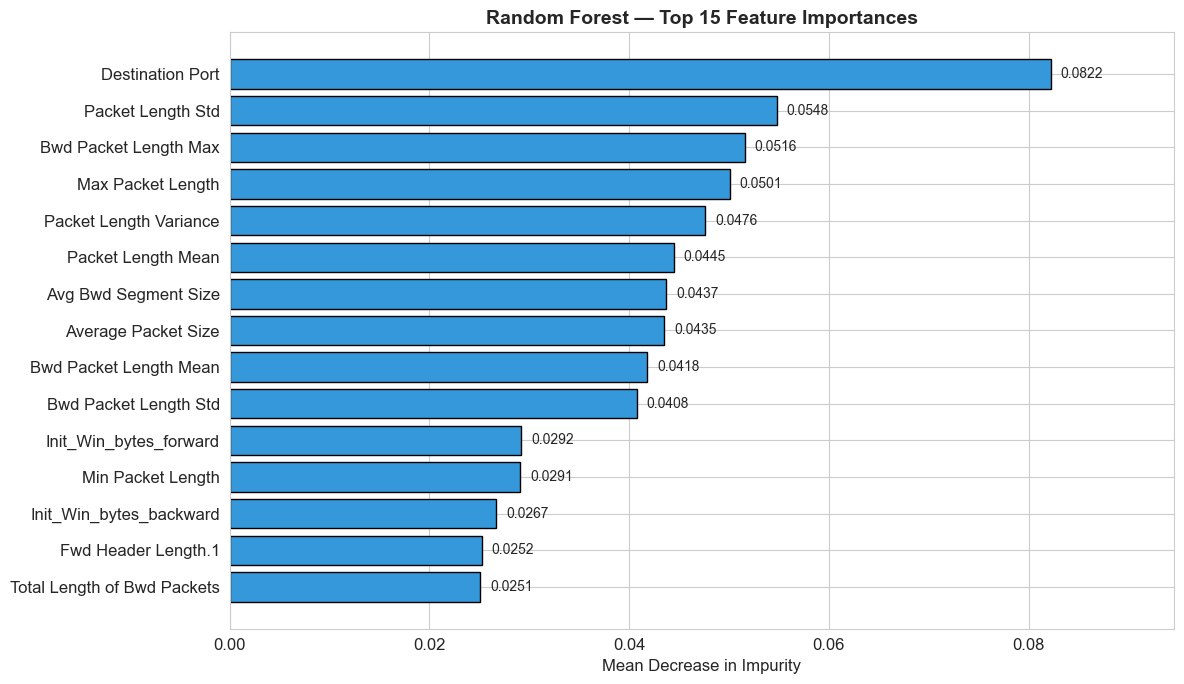


Top feature: 'Destination Port' (0.0822)
Destination Port dominates because certain attacks target specific ports.
This is noted as a generalisation concern for port-agnostic attack variants.


In [8]:
feature_imp = pd.Series(
    rf_final.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print("Top 15 features:")
print(feature_imp.head(15).to_string())

fig, ax = plt.subplots(figsize=(12, 7))
top15 = feature_imp.head(15)
bars = ax.barh(top15.index[::-1], top15.values[::-1], color='#3498db', edgecolor='black')
ax.set_xlabel('Mean Decrease in Impurity', fontsize=12)
ax.set_title('Random Forest — Top 15 Feature Importances', fontsize=14, fontweight='bold')
ax.set_xlim(0, top15.max() * 1.15)
for bar, val in zip(bars, top15.values[::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/03_feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTop feature: '{feature_imp.index[0]}' ({feature_imp.iloc[0]:.4f})")
print("Destination Port dominates because certain attacks target specific ports.")
print("This is noted as a generalisation concern for port-agnostic attack variants.")


---
## 7. Isolation Forest — Unsupervised Anomaly Detection

Isolation Forest learns the **boundary of normal (BENIGN) traffic** without attack labels.
Traffic deviating from this boundary is flagged as anomalous.

This enables detection of **novel attack types** not present in training data —
a key advantage over supervised approaches and directly relevant to concept drift.

The `contamination` parameter is tuned empirically across 5 values.


In [9]:
print(f"IF training data: {X_train_benign.shape[0]:,} BENIGN samples")
print()

contamination_values = [0.10, 0.15, 0.20, 0.25, 0.30]
results = []

for cont in contamination_values:
    iso = IsolationForest(n_estimators=100, contamination=cont, random_state=42, n_jobs=-1)
    iso.fit(X_train_benign)
    pred = iso.predict(X_test_scaled)
    y_pred = np.where(pred == 1, 1, 0)  # 1=normal=BENIGN, -1=anomaly=ATTACK(0)

    attack_idx = y_test_enc == 0
    benign_idx = y_test_enc == 1
    attack_recall = (y_pred[attack_idx] == 0).sum() / attack_idx.sum()
    fpr           = (y_pred[benign_idx] == 0).sum() / benign_idx.sum()
    f1            = f1_score(y_test_enc, y_pred, average='macro')

    results.append({'Contamination': cont, 'Attack Recall': round(attack_recall,4),
                    'FPR': round(fpr,4), 'F1-macro': round(f1,4)})
    print(f"  contamination={cont:.2f} | Attack Recall={attack_recall:.3f} | FPR={fpr:.3f} | F1={f1:.3f}")

results_df = pd.DataFrame(results)
print()
print(results_df.to_string(index=False))


IF training data: 1,400,977 BENIGN samples

  contamination=0.10 | Attack Recall=0.281 | FPR=0.108 | F1=0.594
  contamination=0.15 | Attack Recall=0.285 | FPR=0.161 | F1=0.565
  contamination=0.20 | Attack Recall=0.287 | FPR=0.213 | F1=0.538
  contamination=0.25 | Attack Recall=0.323 | FPR=0.258 | F1=0.531
  contamination=0.30 | Attack Recall=0.350 | FPR=0.295 | F1=0.524

 Contamination  Attack Recall    FPR  F1-macro
          0.10         0.2812 0.1082    0.5935
          0.15         0.2848 0.1615    0.5647
          0.20         0.2866 0.2128    0.5376
          0.25         0.3230 0.2576    0.5314
          0.30         0.3496 0.2946    0.5235


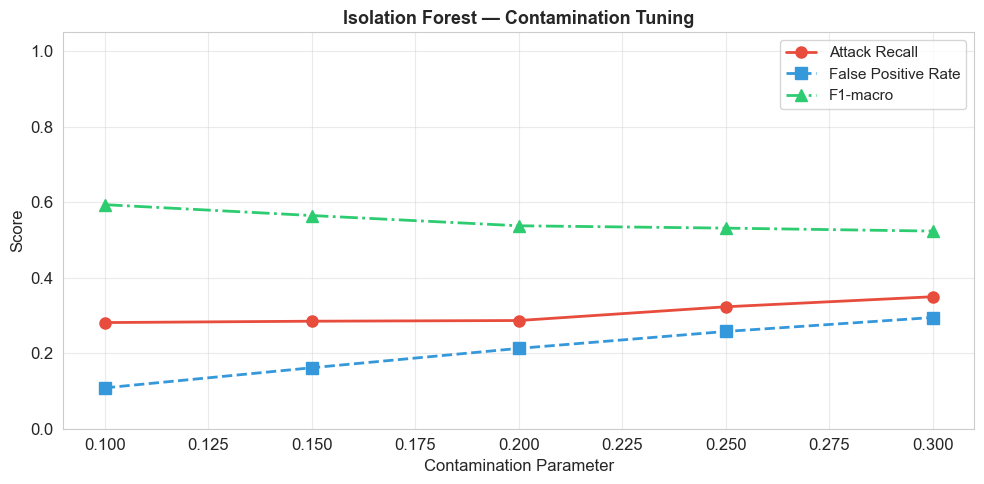

Selected contamination = 0.1


In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(results_df['Contamination'], results_df['Attack Recall'],
        'o-', color='#e74c3c', lw=2, ms=8, label='Attack Recall')
ax.plot(results_df['Contamination'], results_df['FPR'],
        's--', color='#3498db', lw=2, ms=8, label='False Positive Rate')
ax.plot(results_df['Contamination'], results_df['F1-macro'],
        '^-.', color='#2ecc71', lw=2, ms=8, label='F1-macro')
ax.set_xlabel('Contamination Parameter', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Isolation Forest — Contamination Tuning', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/04_isolation_forest_contamination_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

best_cont = results_df.loc[results_df['F1-macro'].idxmax(), 'Contamination']
print(f"Selected contamination = {best_cont}")


---
## 8. Isolation Forest — Final Model

In [11]:
print(f"Training final Isolation Forest (contamination={best_cont})...")
iso_final = IsolationForest(n_estimators=100, contamination=best_cont, random_state=42, n_jobs=-1)
t0 = time.time()
iso_final.fit(X_train_benign)
print(f"  Completed in {time.time()-t0:.1f}s  |  Trees: {iso_final.n_estimators}  |  Trained on: {X_train_benign.shape[0]:,} BENIGN rows")


Training final Isolation Forest (contamination=0.1)...
  Completed in 6.5s  |  Trees: 100  |  Trained on: 1,400,977 BENIGN rows


---
## 9. Save Models

In [12]:
joblib.dump(rf_final,  f'{MODELS_DIR}/random_forest.pkl')
joblib.dump(iso_final, f'{MODELS_DIR}/isolation_forest.pkl')
results_df.to_csv(f'{RESULTS_DIR}/if_contamination_tuning.csv', index=False)

print("Saved to ../models/:")
for fname in sorted(os.listdir(MODELS_DIR)):
    fpath = os.path.join(MODELS_DIR, fname)
    print(f"  {fname}  ({os.path.getsize(fpath)/1024**2:.1f} MB)")

print("\nSaved to ../results/:")
for fname in sorted(os.listdir(RESULTS_DIR)):
    fpath = os.path.join(RESULTS_DIR, fname)
    print(f"  {fname}  ({os.path.getsize(fpath)/1024:.1f} KB)")


Saved to ../models/:
  isolation_forest.pkl  (0.7 MB)
  random_forest.pkl  (20.4 MB)

Saved to ../results/:
  01_class_distribution_before_resampling.png  (67.0 KB)
  02_class_distribution_after_resampling.png  (55.1 KB)
  03_feature_importance_rf.png  (112.6 KB)
  04_isolation_forest_contamination_tuning.png  (57.7 KB)
  if_contamination_tuning.csv  (0.2 KB)


---
## 10. Summary

| Model | Training Data | Imbalance Handling | Status |
|---|---|---|---|
| Random Forest | 1.67M rows | class_weight='balanced' | Saved to models/ |
| Isolation Forest | ~1.4M BENIGN rows | N/A (unsupervised) | Saved to models/ |

**Next step:** Notebook 04 — Evaluation (ROC-AUC, FPR, confusion matrices, RF vs IF comparison)
